## Download Kaggle Dataset

To download a dataset from Kaggle, you need to use the Kaggle API. First, install the `kaggle` library.

## Data Loading and Initial Exploration

Now that the dataset is downloaded and unzipped, we can load the `games.csv` file into a pandas DataFrame and perform initial exploration, similar to your examples.

In [6]:
import pandas as pd

# Load the chess games data from the CSV file
# Assuming the main data file is named 'games.csv' after unzipping
df_chess = pd.read_csv('games.csv')

print('First 5 rows of the dataset:')
display(df_chess.head())

print('\nDataset Information:')
df_chess.info()

print('\nDescriptive Statistics:')
display(df_chess.describe())

First 5 rows of the dataset:


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usa

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


## Creating a SQLite Database from DataFrame

I will create a SQLite database named `chess.db` and save the `df_chess` DataFrame into a table called `chess_games`.

In [7]:
import sqlite3

# Connect to a SQLite database (this will create the file if it doesn't exist)
conn = sqlite3.connect("chess.db")

# Write the DataFrame to a SQL table
df_chess.to_sql("chess_games", conn, if_exists="replace", index=False)

# Close the connection
conn.close()

print("SQLite database 'chess.db' created successfully with table 'chess_games'!")

SQLite database 'chess.db' created successfully with table 'chess_games'!


## Importing Data from SQLite Database

Now, let's query the `chess_games` table from the `chess.db` database and load it back into a pandas DataFrame to confirm the database was created successfully.

In [8]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("chess.db")
print('Connection to chess.db successful!')

# Read data from the 'chess_games' table into a DataFrame
df_from_db = pd.read_sql_query("SELECT * FROM chess_games;", conn)

# Close the connection
conn.close()

print('\nFirst 5 rows of data imported from the database:')
display(df_from_db.head())

print('\nInformation of data imported from the database:')
df_from_db.info()

Connection to chess.db successful!

First 5 rows of data imported from the database:


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,0,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,1,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,1,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,1,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,1,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5



Information of data imported from the database:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  int64  
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: float64(2), int64(5), ob

## Exporting DataFrame to CSV

I will now export the `df_chess` DataFrame (which contains the chess game data) to a CSV file named `chess_games.csv`.

In [9]:
import pandas as pd

# Export the DataFrame to a new CSV file
df_chess.to_csv("chess_games.csv", index=False)
print("DataFrame exported to chess_games.csv successfully!")

DataFrame exported to chess_games.csv successfully!


## Exporting DataFrame to JSON

Next, I will export the `df_chess` DataFrame to a JSON file named `chess_games.json`.

In [10]:
import pandas as pd

# Export the DataFrame to a JSON file
df_chess.to_json("chess_games.json", orient="records", indent=4)
print("DataFrame exported to chess_games.json successfully!")

# Display the first 700 characters of the JSON file to verify
with open("chess_games.json", "r") as file:
    print("\nFirst few lines of chess_games.json:\n", file.read()[:700])

DataFrame exported to chess_games.json successfully!

First few lines of chess_games.json:
 [
    {
        "id":"TZJHLljE",
        "rated":false,
        "created_at":1504210000000.0,
        "last_move_at":1504210000000.0,
        "turns":13,
        "victory_status":"outoftime",
        "winner":"white",
        "increment_code":"15+2",
        "white_id":"bourgris",
        "white_rating":1500,
        "black_id":"a-00",
        "black_rating":1191,
        "moves":"d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5 Bf4",
        "opening_eco":"D10",
        "opening_name":"Slav Defense: Exchange Variation",
        "opening_ply":5
    },
    {
        "id":"l1NXvwaE",
        "rated":true,
        "created_at":1504130000000.0,
        "last_move_at":1504130000000.0,
        "turn


## Creating a Visualization

Finally, let's create a simple visualization. Based on the dataset, we can analyze the distribution of `victory_status` or the `winner`. Let's plot the distribution of `victory_status`.

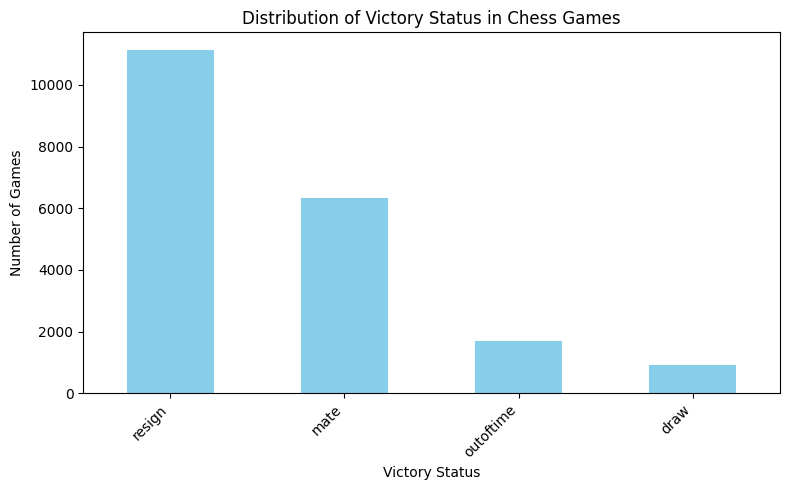

In [11]:
import matplotlib.pyplot as plt

# Calculate the count of each victory status
victory_counts = df_chess['victory_status'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 5))
victory_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Victory Status in Chess Games')
plt.xlabel('Victory Status')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze Distribution of Winners

Now, let's look at the distribution of game winners (white, black, or draw) in the dataset.

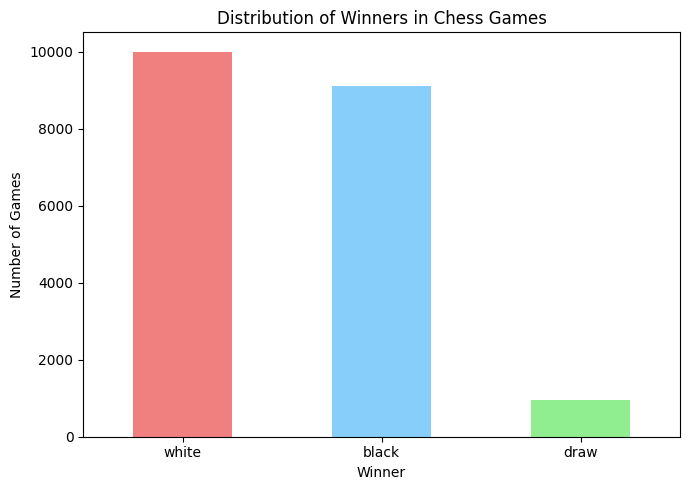

In [12]:
import matplotlib.pyplot as plt

# Calculate the count of each winner type
winner_counts = df_chess['winner'].value_counts()

# Create a bar plot for winner distribution
plt.figure(figsize=(7, 5))
winner_counts.plot(kind='bar', color=['lightcoral', 'lightskyblue', 'lightgreen'])
plt.title('Distribution of Winners in Chess Games')
plt.xlabel('Winner')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Percentage of Games Won by White vs. Black

Let's calculate the percentage of games won by white and black, excluding draws.

In [13]:
# Get the counts for white and black wins from the 'winner_counts' Series
white_wins = winner_counts['white']
black_wins = winner_counts['black']

# Calculate the total number of decisive games (excluding draws)
total_decisive_games = white_wins + black_wins

# Calculate percentages
percentage_white_wins = (white_wins / total_decisive_games) * 100
percentage_black_wins = (black_wins / total_decisive_games) * 100

print(f"Percentage of games won by White: {percentage_white_wins:.2f}%")
print(f"Percentage of games won by Black: {percentage_black_wins:.2f}%")

Percentage of games won by White: 52.34%
Percentage of games won by Black: 47.66%
